# PD Model Training — Logistic Regression Scorecard

Train a Probability of Default (PD) model on feature-selected Lending Club data.

**Pipeline**
1. Read data from `imp_features/`
2. Imputation (train-fit, apply to all splits)
3. WoE transformation via optimal binning
4. Optuna hyperparameter search
5. Final logistic regression training
6. Feature importance — SHAP & coefficient gain
7. Select top 5 features (SHAP + gain)
8. Model analysis — KS & AUC on train / validation / OOT

## Imports | Configs

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import optuna
import shap
import sklearn
from IPython.display import display
from optbinning import OptimalBinning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.utils import check_array

# optbinning / sklearn >= 1.6 compatibility
def safe_check_array(X, **kwargs):
    if "force_all_finite" in kwargs and sklearn.__version__ >= "1.6":
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return check_array(X, **kwargs)

# --- Config ---
ROOT = os.path.join("data_processing", "data", "imp_features")
TARGET = "default_status"
RANDOM_STATE = 42

BINNING_SAMPLE_SIZE = 100_000   # stratified sample for WoE bin fitting
OPTUNA_SAMPLE_SIZE = 100_000    # stratified sample for hyperparameter search
SHAP_SAMPLE_SIZE = 10_000
OPTUNA_TRIALS = 30
IV_THRESHOLD = 0.02             # drop WoE features below this IV on train sample

# --- Read data ---
full_df = pd.read_csv(os.path.join(ROOT, "full_df_fi.csv"))
train_df = pd.read_csv(os.path.join(ROOT, "train_fi.csv"))
test_df = pd.read_csv(os.path.join(ROOT, "test_fi.csv"))
oot_df = pd.read_csv(os.path.join(ROOT, "oot_fi.csv"))

FEATURE_COLS = [c for c in train_df.columns if c != TARGET]

print(f"full_df : {full_df.shape} | train : {train_df.shape} | test : {test_df.shape} | oot : {oot_df.shape}")
print(f"Features: {len(FEATURE_COLS)}")
for split_name, split_df in [("train", train_df), ("test", test_df), ("oot", oot_df)]:
    bad_rate = split_df[TARGET].mean() * 100
    print(f"{split_name:>5} bad rate: {bad_rate:.2f}%")

full_df : (2260668, 36) | train : (1582467, 36) | test : (339100, 36) | oot : (339101, 36)
Features: 35
train bad rate: 15.66%
 test bad rate: 5.49%
  oot bad rate: 0.88%


## Imputation

 Missing values are imputed using **train-only** statistics to prevent leakage:
 - **Numeric** → median
- **Categorical / object** → `"MISSING"`

In [2]:
DATE_COLS = ["issue_d", "last_pymnt_d", "next_pymnt_d", "last_credit_pull_d"]

def preprocess_dates(df):
    out = df.copy()
    for col in DATE_COLS:
        if col not in out.columns:
            continue
        if col == "issue_d":
            out[col] = pd.to_datetime(out[col], errors="coerce")
        else:
            out[col] = pd.to_datetime(out[col], format="%b-%Y", errors="coerce")
        out[col] = out[col].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
    return out

def impute_fit_transform(train, *splits):
    train = preprocess_dates(train)
    splits = [preprocess_dates(s) for s in splits]

    impute_values = {}
    for col in FEATURE_COLS:
        if pd.api.types.is_numeric_dtype(train[col]):
            impute_values[col] = train[col].median()
        else:
            impute_values[col] = "MISSING"

    def _apply(df):
        out = df.copy()
        for col in FEATURE_COLS:
            out[col] = out[col].fillna(impute_values[col])
            if not pd.api.types.is_numeric_dtype(out[col]):
                out[col] = out[col].astype(str)
        return out

    return _apply(train), *[_apply(s) for s in splits], impute_values

train_imp, test_imp, oot_imp, impute_values = impute_fit_transform(
    train_df, test_df, oot_df
)

missing_report = pd.DataFrame({
    "column": FEATURE_COLS,
    "train_null_pct": (train_df[FEATURE_COLS].isnull().mean() * 100).round(2).values,
    "impute_value": [impute_values[c] for c in FEATURE_COLS],
})
print(f"Imputed {train_df[FEATURE_COLS].isnull().sum().sum():,} missing values in train")
missing_report.sort_values("train_null_pct", ascending=False).head(10)

Imputed 13,660,021 missing values in train


,column,train_null_pct,impute_value
6,next_pymnt_d,77.89,737150.0
32,il_util,60.69,73.0
26,mths_since_rcnt_il,55.95,13.0
19,all_util,54.74,61.0
20,open_rv_12m,54.73,1.0
25,max_bal_bc,54.73,4426.0
27,inq_fi,54.73,0.0
21,open_il_12m,54.73,0.0
16,open_rv_24m,54.73,2.0
18,open_acc_6m,54.73,1.0


## WoE Transformation
Optimal binning is **fit on a stratified train sample** and applied to train / validation / OOT. Each feature is encoded as its Weight of Evidence (WoE) value.

In [3]:
def fit_woe_binners(train, feature_cols, target, sample_size, random_state=42):
    sample_frac = min(1.0, sample_size / len(train))
    bin_sample, _ = train_test_split(
        train,
        train_size=sample_frac,
        stratify=train[target],
        random_state=random_state,
    )

    binners = {}
    iv_report = []

    for col in feature_cols:
        X = bin_sample[col]
        y = bin_sample[target]
        dtype = "numerical" if pd.api.types.is_numeric_dtype(X) else "categorical"

        try:
            optb = OptimalBinning(name=col, dtype=dtype, solver="cp")
            optb.fit(X, y)
            iv = optb.binning_table.build()["IV"].sum()
            binners[col] = optb
            iv_report.append({"feature": col, "iv": iv, "status": "ok"})
        except Exception as exc:
            iv_report.append({"feature": col, "iv": np.nan, "status": str(exc)})

    iv_df = pd.DataFrame(iv_report).sort_values("iv", ascending=False)
    selected = iv_df.loc[
        (iv_df["status"] == "ok") & (iv_df["iv"] >= IV_THRESHOLD), "feature"
    ].tolist()

    return {k: v for k, v in binners.items() if k in selected}, iv_df, selected


def transform_woe(df, binners, feature_cols):
    out = pd.DataFrame(index=df.index)
    for col in feature_cols:
        if col in binners:
            out[col] = binners[col].transform(df[col], metric="woe")
        else:
            out[col] = 0.0
    return out


binners, iv_df, woe_features = fit_woe_binners(
    train_imp, FEATURE_COLS, TARGET, BINNING_SAMPLE_SIZE, RANDOM_STATE
)

X_train_woe = transform_woe(train_imp, binners, woe_features)
X_test_woe = transform_woe(test_imp, binners, woe_features)
X_oot_woe = transform_woe(oot_imp, binners, woe_features)

y_train = train_imp[TARGET].values
y_test = test_imp[TARGET].values
y_oot = oot_imp[TARGET].values

print(f"WoE features retained: {len(woe_features)} / {len(FEATURE_COLS)}")
iv_df.head(10)

WoE features retained: 29 / 35


,feature,iv,status
0,emp_title,11.722207,ok
1,last_fico_range_high,7.972842,ok
2,last_fico_range_low,7.972842,ok
7,last_pymnt_amnt,5.996036,ok
9,total_rec_prncp,4.268328,ok
5,last_pymnt_d,2.855924,ok
14,total_pymnt,1.574501,ok
15,total_pymnt_inv,1.569753,ok
11,sub_grade,0.886740,ok
13,int_rate,0.858387,ok


## Optuna Hyperparameter Search

Logistic regression hyperparameters are tuned on a stratified train sample. **Validation AUC** is the optimization objective.

In [4]:
sample_frac = min(1.0, OPTUNA_SAMPLE_SIZE / len(X_train_woe))
X_opt, _, y_opt, _ = train_test_split(
    X_train_woe[woe_features],
    y_train,
    train_size=sample_frac,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_val = X_test_woe[woe_features]
y_val = y_test

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    solver = "liblinear" if penalty == "l1" else "lbfgs"
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        class_weight=class_weight,
        solver=solver,
        max_iter=500,
        random_state=RANDOM_STATE,
    )
    model.fit(X_opt, y_opt)
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)


study = optuna.create_study(direction="maximize", study_name="lr_pd_model")
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
print("Best validation AUC :", round(study.best_value, 4))
print("Best parameters     :", best_params)

Best trial: 24. Best value: 0.990936: 100%|██████████| 30/30 [00:37<00:00,  1.26s/it]

Best validation AUC : 0.9909
Best parameters     : {'penalty': 'l1', 'C': 1.4078975036217036, 'class_weight': None}


## Final Model Training

Retrain logistic regression on the **full training set** using Optuna-selected hyperparameters.

In [5]:
solver = "liblinear" if best_params["penalty"] == "l1" else "lbfgs"

final_model = LogisticRegression(
    penalty=best_params["penalty"],
    C=best_params["C"],
    class_weight=best_params["class_weight"],
    solver=solver,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
final_model.fit(X_train_woe[woe_features], y_train)

print("Trained on", f"{len(y_train):,}", "rows with", len(woe_features), "WoE features")

Trained on 1,582,467 rows with 29 WoE features


## Feature Importance — SHAP & Gain

- **SHAP**: mean absolute SHAP value from `LinearExplainer` (10k train sample)
- **Gain**: absolute logistic regression coefficient on WoE features

Top 10 features by gain (|coefficient|)


,feature,gain
0,total_pymnt,4.335190
1,total_rec_prncp,3.449147
2,total_bal_il,3.149127
3,last_pymnt_d,2.085968
4,max_bal_bc,1.949911
5,bc_open_to_buy,1.480733
6,int_rate,1.132513
7,last_pymnt_amnt,1.102680
8,fico_range_high,0.899148
9,sub_grade,0.831913


Background dataset has 10000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=10000 when initializing the masker.


Top 10 features by SHAP


,feature,mean_abs_shap
0,total_rec_prncp,4.630940
1,last_pymnt_d,3.687963
2,last_pymnt_amnt,3.353569
3,total_pymnt,3.197945
4,last_fico_range_high,1.287335
5,int_rate,0.641461
6,sub_grade,0.478260
7,last_fico_range_low,0.437646
8,total_pymnt_inv,0.407523
9,total_bal_il,0.382332


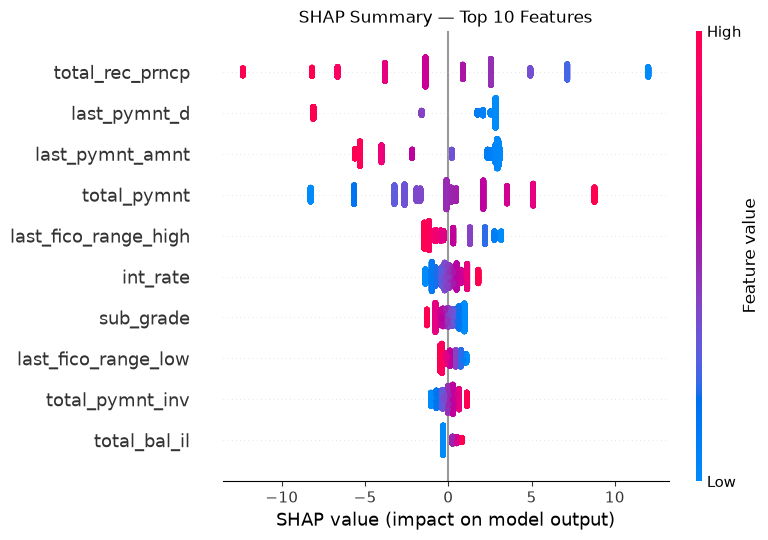

In [6]:
# --- Gain (|coefficient|) ---
gain_df = pd.DataFrame({
    "feature": woe_features,
    "gain": np.abs(final_model.coef_[0]),
}).sort_values("gain", ascending=False)

top10_gain = gain_df.head(10).reset_index(drop=True)
print("Top 10 features by gain (|coefficient|)")
display(top10_gain)

# --- SHAP ---
shap_sample = X_train_woe[woe_features].sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_train_woe)),
    random_state=RANDOM_STATE,
)
explainer = shap.LinearExplainer(final_model, shap_sample, feature_perturbation="interventional")
shap_values = explainer.shap_values(shap_sample)

shap_df = pd.DataFrame({
    "feature": woe_features,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

top10_shap = shap_df.head(10).reset_index(drop=True)
print("Top 10 features by SHAP")
display(top10_shap)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=10)
plt.title("SHAP Summary — Top 10 Features")
plt.tight_layout()
plt.show()

## Top 5 Feature Selection

Rank features by average rank across SHAP and gain, then retrain the final model on the selected top 5.

In [7]:
importance = shap_df.merge(gain_df, on="feature", how="outer")
importance["shap_rank"] = importance["mean_abs_shap"].rank(ascending=False, method="min")
importance["gain_rank"] = importance["gain"].rank(ascending=False, method="min")
importance["avg_rank"] = (importance["shap_rank"] + importance["gain_rank"]) / 2
importance = importance.sort_values("avg_rank")

top5_features = importance.head(5)["feature"].tolist()
print("Top 5 features (SHAP + gain):")
for i, feat in enumerate(top5_features, 1):
    row = importance.loc[importance["feature"] == feat].iloc[0]
    print(
        f"  {i}. {feat} | shap={row['mean_abs_shap']:.4f} "
        f"| gain={row['gain']:.4f} | avg_rank={row['avg_rank']:.1f}"
    )

final_model_top5 = LogisticRegression(
    penalty=best_params["penalty"],
    C=best_params["C"],
    class_weight=best_params["class_weight"],
    solver=solver,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
final_model_top5.fit(X_train_woe[top5_features], y_train)
importance.head(10)

Top 5 features (SHAP + gain):
  1. total_rec_prncp | shap=4.6309 | gain=3.4491 | avg_rank=1.5
  2. total_pymnt | shap=3.1979 | gain=4.3352 | avg_rank=2.5
  3. last_pymnt_d | shap=3.6880 | gain=2.0860 | avg_rank=3.0
  4. last_pymnt_amnt | shap=3.3536 | gain=1.1027 | avg_rank=5.5
  5. int_rate | shap=0.6415 | gain=1.1325 | avg_rank=6.5


,feature,mean_abs_shap,gain,shap_rank,gain_rank,avg_rank
27,total_rec_prncp,4.630940,3.449147,1.0,2.0,1.5
25,total_pymnt,3.197945,4.335190,4.0,1.0,2.5
14,last_pymnt_d,3.687963,2.085968,2.0,4.0,3.0
13,last_pymnt_amnt,3.353569,1.102680,3.0,8.0,5.5
8,int_rate,0.641461,1.132513,6.0,7.0,6.5
24,total_bal_il,0.382332,3.149127,10.0,3.0,6.5
22,sub_grade,0.478260,0.831913,7.0,10.0,8.5
1,bc_open_to_buy,0.297081,1.480733,11.0,6.0,8.5
15,max_bal_bc,0.240543,1.949911,13.0,5.0,9.0
11,last_fico_range_high,1.287335,0.661834,5.0,14.0,9.5


## Model Analysis — KS & AUC

Evaluate the **top-5 feature model** on train, validation, and OOT splits.

Performance — Top 5 Feature Model


,split,auc,ks
0,train,0.9780,0.8563
1,validation,0.9872,0.9111
2,oot,0.9812,0.9089


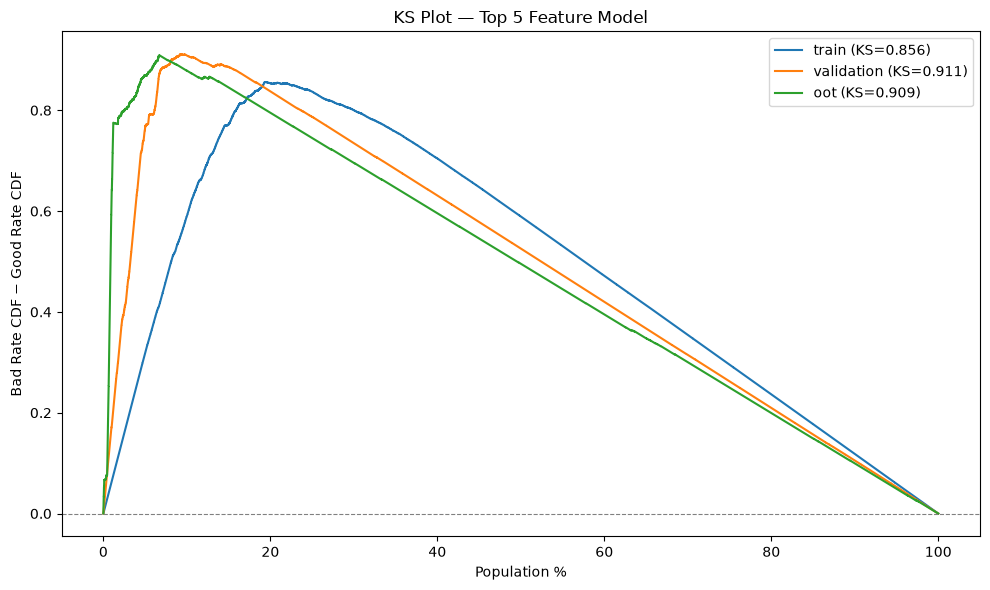

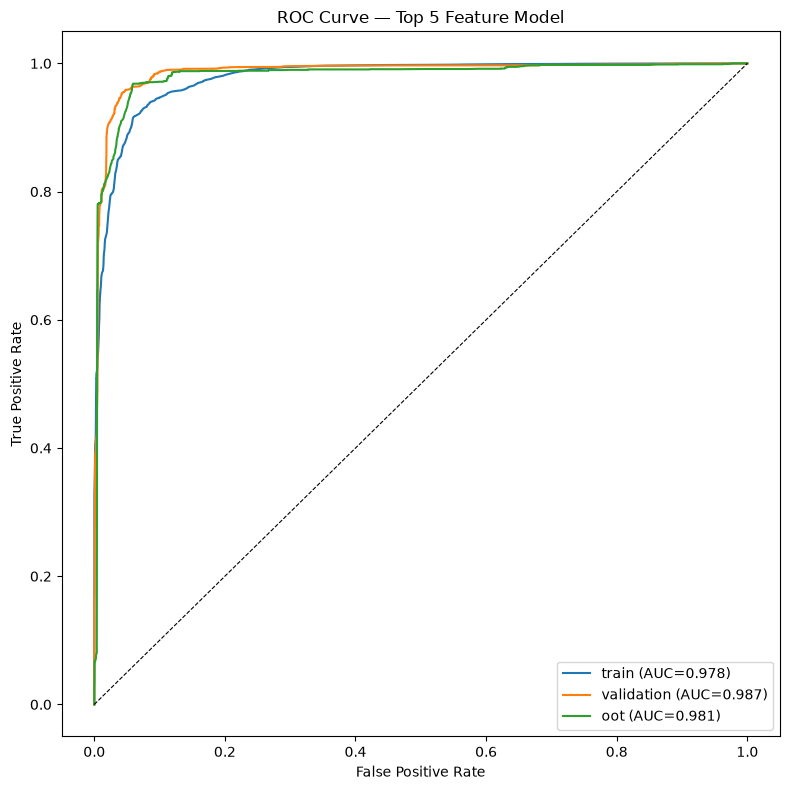

In [8]:
def calc_ks(y_true, y_score):
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    bad_rate = y_sorted.cumsum() / y_sorted.sum()
    good_rate = (1 - y_sorted).cumsum() / (1 - y_sorted).sum()
    return np.max(np.abs(bad_rate - good_rate))


def ks_curve(y_true, y_score):
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    pct = np.arange(1, len(y_sorted) + 1) / len(y_sorted) * 100
    bad_rate = y_sorted.cumsum() / y_sorted.sum()
    good_rate = (1 - y_sorted).cumsum() / (1 - y_sorted).sum()
    return pct, bad_rate - good_rate


def evaluate_split(model, X, y, split_name):
    prob = model.predict_proba(X)[:, 1]
    return {
        "split": split_name,
        "auc": roc_auc_score(y, prob),
        "ks": calc_ks(y, prob),
        "prob": prob,
    }


splits = {
    "train": (X_train_woe[top5_features], y_train),
    "validation": (X_test_woe[top5_features], y_test),
    "oot": (X_oot_woe[top5_features], y_oot),
}

results = [evaluate_split(final_model_top5, X, y, name) for name, (X, y) in splits.items()]
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k != "prob"} for r in results])
print("Performance — Top 5 Feature Model")
display(metrics_df.round(4))

# --- KS Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
for r in results:
    y = splits[r["split"]][1]
    pct, ks_diff = ks_curve(y, r["prob"])
    ax.plot(pct, ks_diff, label=f"{r['split']} (KS={r['ks']:.3f})")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Population %")
ax.set_ylabel("Bad Rate CDF − Good Rate CDF")
ax.set_title("KS Plot — Top 5 Feature Model")
ax.legend()
plt.tight_layout()
plt.show()

# --- ROC / AUC Plot ---
fig, ax = plt.subplots(figsize=(8, 8))
for r in results:
    y = splits[r["split"]][1]
    fpr, tpr, _ = roc_curve(y, r["prob"])
    ax.plot(fpr, tpr, label=f"{r['split']} (AUC={r['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Top 5 Feature Model")
ax.legend()
plt.tight_layout()
plt.show()